# UCI HAR Baseline Model

This notebook develops a reproducible baseline model for classifying the six activities in the UCI Human Activity Recognition dataset.

The objectives are to:

1. load and inspect the preprocessed dataset;
2. define a simple one-dimensional convolutional neural network;
3. train the model using the training and validation sets;
4. inspect the learning curves; and
5. evaluate the final model on the test set.

The test set will remain untouched until the model design and training decisions have been finalised.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

In [2]:
# Locate the project root whether the notebook is launched
# from the project directory or the notebooks directory.
PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

PROCESSED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "uci_har_preprocessed.npz"
)

if not PROCESSED_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Processed dataset not found: {PROCESSED_DATA_PATH}"
    )

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed dataset: {PROCESSED_DATA_PATH}")

Project root: D:\Lunacia\Machine Learning
Processed dataset: D:\Lunacia\Machine Learning\data\processed\uci_har_preprocessed.npz


## Loading the Preprocessed Dataset

The previous notebook saved the training, validation, and test splits in a compressed NumPy archive.

Each feature array has the shape:

`(samples, time steps, sensor channels)`

The activity names and sensor channel names are loaded from the same file so that the model outputs can be interpreted consistently.

In [3]:
with np.load(PROCESSED_DATA_PATH) as processed_data:
    X_train = processed_data["X_train"]
    y_train = processed_data["y_train"]

    X_validation = processed_data["X_validation"]
    y_validation = processed_data["y_validation"]

    X_test = processed_data["X_test"]
    y_test = processed_data["y_test"]

    sensor_channels = processed_data["sensor_channels"]
    activity_names = processed_data["activity_names"]

## Inspecting the Loaded Data

Before constructing the model, the dataset dimensions and metadata should be inspected.

The feature arrays are expected to contain:

- 128 time steps per sample;
- 9 sensor channels; and
- one zero-based activity label per sample.

In [4]:
print(f"Training features: {X_train.shape}")
print(f"Training labels: {y_train.shape}")

print()

print(f"Validation features: {X_validation.shape}")
print(f"Validation labels: {y_validation.shape}")

print()

print(f"Test features: {X_test.shape}")
print(f"Test labels: {y_test.shape}")

print()

print(
    f"Sensor channels ({len(sensor_channels)}): "
    f"{sensor_channels.tolist()}"
)

print(
    f"Activities ({len(activity_names)}): "
    f"{activity_names.tolist()}"
)

Training features: (5952, 128, 9)
Training labels: (5952,)

Validation features: (1400, 128, 9)
Validation labels: (1400,)

Test features: (2947, 128, 9)
Test labels: (2947,)

Sensor channels (9): ['body_acc_x', 'body_acc_y', 'body_acc_z', 'body_gyro_x', 'body_gyro_y', 'body_gyro_z', 'total_acc_x', 'total_acc_y', 'total_acc_z']
Activities (6): ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


## Preparing the Modelling Environment

TensorFlow and Keras will be used to construct and train the baseline one-dimensional convolutional neural network.

A fixed random seed is used to make the training process more reproducible.

In [5]:
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


## Defining the Baseline 1D CNN

A one-dimensional convolutional neural network is used to learn temporal patterns from the sensor signals.

The baseline architecture contains:

- a convolutional layer for detecting short local patterns;
- a pooling layer for reducing the temporal resolution;
- a second convolutional layer for learning higher-level patterns;
- global average pooling for summarising each feature map;
- a fully connected layer with dropout; and
- a softmax output layer for the six activity classes.

In [6]:
model = keras.Sequential(
    [
        layers.Input(
            shape=X_train.shape[1:],
        ),

        layers.Conv1D(
            filters=64,
            kernel_size=5,
            padding="same",
            activation="relu",
        ),

        layers.MaxPooling1D(
            pool_size=2,
        ),

        layers.Conv1D(
            filters=128,
            kernel_size=3,
            padding="same",
            activation="relu",
        ),

        layers.GlobalAveragePooling1D(),

        layers.Dense(
            units=64,
            activation="relu",
        ),

        layers.Dropout(
            rate=0.3,
        ),

        layers.Dense(
            units=len(activity_names),
            activation="softmax",
        ),
    ],
    name="uci_har_baseline",
)

model.summary()

Model: "uci_har_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 64)        │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,294 (141.77 KB)

 Trainable params: 36,294 (141.77 KB)

 Non-trainable params: 0 (0.00 B)

## Compiling the Model

The model is configured with:

- the Adam optimiser for updating the model parameters;
- sparse categorical cross-entropy for comparing integer class labels with the predicted probabilities; and
- classification accuracy for monitoring model performance.

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001,
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy",
        ),
    ],
)

## Training the Baseline Model

The model is trained using the training split, while the validation split is used to monitor generalisation performance.

Early stopping terminates training when the validation loss no longer improves and restores the model parameters from the best-performing epoch.

The test set is not used during training or model selection.

In [8]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(
        X_validation,
        y_validation,
    ),
    epochs=50,
    batch_size=64,
    callbacks=[
        early_stopping,
    ],
    verbose=1,
)

Epoch 1/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7403 - loss: 0.7152 - val_accuracy: 0.8757 - val_loss: 0.3901
Epoch 2/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9439 - loss: 0.1668 - val_accuracy: 0.8886 - val_loss: 0.3722
Epoch 3/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9600 - loss: 0.1182 - val_accuracy: 0.8936 - val_loss: 0.3885
Epoch 4/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9565 - loss: 0.1103 - val_accuracy: 0.8986 - val_loss: 0.3960
Epoch 5/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9609 - loss: 0.0972 - val_accuracy: 0.8964 - val_loss: 0.4060
Epoch 6/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9619 - loss: 0.0944 - val_accuracy: 0.8907 - val_loss: 0.4436
Epoch 7/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9656 - loss: 0.0891 - val_accuracy: 0.8907 - val_loss: 0.4855
Epoch 8/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9640 - loss: 0.0837 - val_accuracy: 0.8979 - val_loss:

## Inspecting the Learning Curves

The training history is visualised to compare performance on the training and validation sets.

A growing difference between the training and validation results may indicate overfitting, while consistently poor results on both sets may indicate underfitting.

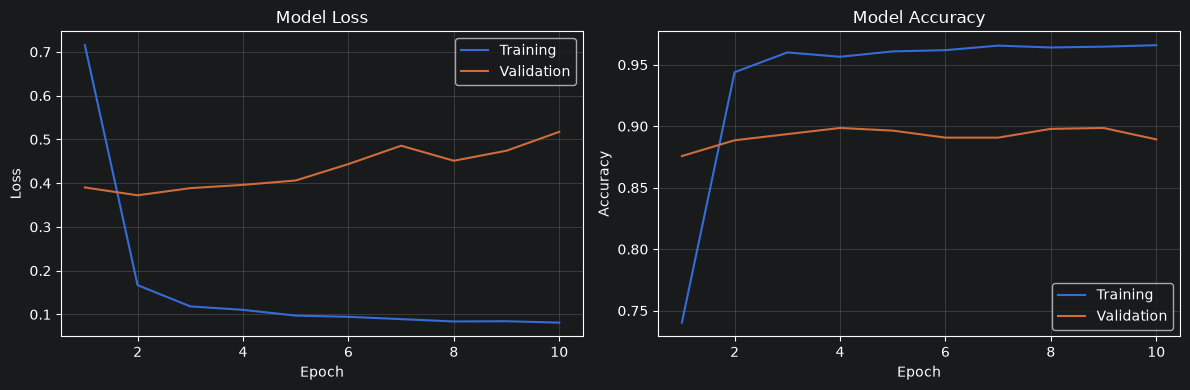

In [9]:
training_epochs = np.arange(
    1,
    len(history.history["loss"]) + 1,
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 4),
)

axes[0].plot(
    training_epochs,
    history.history["loss"],
    label="Training",
)

axes[0].plot(
    training_epochs,
    history.history["val_loss"],
    label="Validation",
)

axes[0].set_title("Model Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    training_epochs,
    history.history["accuracy"],
    label="Training",
)

axes[1].plot(
    training_epochs,
    history.history["val_accuracy"],
    label="Validation",
)

axes[1].set_title("Model Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluating the Baseline Model

The model selected using the validation loss is evaluated once on the test set.

The test data has not been used for training, early stopping, or model selection. Its performance therefore provides an independent estimate of how well the baseline model generalises to unseen subjects.

In [10]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    batch_size=64,
    verbose=0,
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss: 0.4066
Test accuracy: 0.8985


## Analysing the Confusion Matrix

A confusion matrix is used to examine how the six activities are classified.

The model probabilities are converted into predicted class labels by selecting the class with the highest probability. The rows represent the actual activities, while the columns represent the predicted activities.

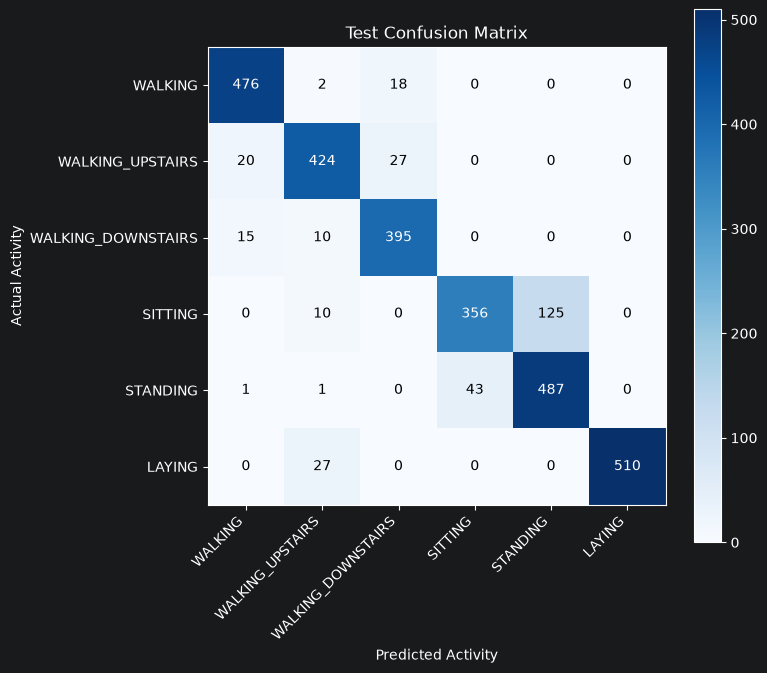

In [11]:
test_probabilities = model.predict(
    X_test,
    batch_size=64,
    verbose=0,
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1,
)

confusion_matrix = tf.math.confusion_matrix(
    y_test,
    test_predictions,
    num_classes=len(activity_names),
).numpy()

fig, ax = plt.subplots(
    figsize=(8, 7),
)

matrix_image = ax.imshow(
    confusion_matrix,
    cmap="Blues",
)

fig.colorbar(
    matrix_image,
    ax=ax,
)

class_positions = np.arange(
    len(activity_names)
)

ax.set_xticks(
    class_positions,
    labels=activity_names,
    rotation=45,
    ha="right",
)

ax.set_yticks(
    class_positions,
    labels=activity_names,
)

ax.set_title("Test Confusion Matrix")
ax.set_xlabel("Predicted Activity")
ax.set_ylabel("Actual Activity")

annotation_threshold = confusion_matrix.max() / 2

for actual_index in range(len(activity_names)):
    for predicted_index in range(len(activity_names)):
        count = confusion_matrix[
            actual_index,
            predicted_index,
        ]

        text_colour = (
            "white"
            if count > annotation_threshold
            else "black"
        )

        ax.text(
            predicted_index,
            actual_index,
            count,
            ha="center",
            va="center",
            color=text_colour,
        )

plt.tight_layout()
plt.show()

## Evaluating Class-Level Performance

A classification report is used to evaluate each activity separately.

The report includes:

- precision, which measures how often predictions for a class are correct;
- recall, which measures how many actual samples of a class are identified;
- F1-score, which balances precision and recall; and
- support, which is the number of test samples in each class.

Macro averages treat all activities equally, while weighted averages account for differences in class frequency.

In [12]:
class_report = classification_report(
    y_test,
    test_predictions,
    target_names=activity_names,
    digits=4,
)

print(class_report)

                    precision    recall  f1-score   support

           WALKING     0.9297    0.9597    0.9444       496
  WALKING_UPSTAIRS     0.8945    0.9002    0.8974       471
WALKING_DOWNSTAIRS     0.8977    0.9405    0.9186       420
           SITTING     0.8922    0.7251    0.8000       491
          STANDING     0.7958    0.9154    0.8514       532
            LAYING     1.0000    0.9497    0.9742       537

          accuracy                         0.8985      2947
         macro avg     0.9017    0.8984    0.8977      2947
      weighted avg     0.9019    0.8985    0.8978      2947



## Summary

A baseline one-dimensional convolutional neural network was developed for classifying the six activities in the UCI HAR dataset.

The model:

- uses two one-dimensional convolutional layers to learn temporal sensor patterns;
- reduces the temporal resolution with max pooling;
- summarises the learned feature maps with global average pooling;
- applies dropout to reduce overfitting; and
- produces activity probabilities through a six-class softmax output layer.

Early stopping monitored the validation loss and restored the model parameters from the best-performing epoch. The learning curves showed that the training performance continued to improve while the validation loss reached its minimum during the early epochs and subsequently increased, while the validation accuracy remained around 89–90%, indicating overfitting.

The test loss, accuracy, macro F1-score and weighted F1-score are calculated in the evaluation cells above. Refer to those outputs for the current run rather than maintaining a second copy of the numerical results here.

The model performed particularly well on `WALKING`, `WALKING_DOWNSTAIRS`, and `LAYING`. The main source of error was confusion between `SITTING` and `STANDING`, with `SITTING` producing the lowest recall in the saved classification report.

This notebook establishes a standalone supervised baseline. Notebook 04 reruns the same classification architecture under matched conditions for its 100% and 10% label experiments. Use that notebook's comparison table for claims about the effect of masked pretraining; do not mix its results with a separate run here.